In [4]:
import numpy as np
data = np.load('morocco_processed_dataset/combined/combined_20200321_032743.npz')
print('Keys:', data.files)
print('Shapes:')
for k in data.files:
    print(f'{k}: {data[k].shape}')
print('Channels:', data['channels'])
print('Timestamp:', data['timestamp'])

Keys: ['data', 'timestamp', 'channels']
Shapes:
data: (4, 557, 521)
timestamp: ()
channels: (4,)
Channels: ['satellite' 'wind_u' 'wind_v' 'wind_speed']
Timestamp: 20200321_032743


In [5]:
import os
import matplotlib.pyplot as plt

# Inspect satellite data
sat_file = 'morocco_processed_dataset/satellite_images/sat_20200321_032743.npz'
sat_data = np.load(sat_file)
print('Satellite Keys:', sat_data.files)
for k in sat_data.files:
    print(f'{k}: {sat_data[k].shape}')
print('Satellite Channels:', sat_data['channels'] if 'channels' in sat_data.files else 'No channels key')

# Inspect wind data
wind_file = 'morocco_processed_dataset/wind_data/wind_20200321_033500.npz'
wind_data = np.load(wind_file)
print('\nWind Keys:', wind_data.files)
for k in wind_data.files:
    print(f'{k}: {wind_data[k].shape}')
print('Wind Variables:', wind_data['variables'] if 'variables' in wind_data.files else 'No variables key')

Satellite Keys: ['IR_108', 'IR_120', 'VIS006', 'VIS008', 'timestamp']
IR_108: (557, 521)
IR_120: (557, 521)
VIS006: (557, 521)
VIS008: (557, 521)
timestamp: ()
Satellite Channels: No channels key

Wind Keys: ['wind_u', 'wind_v', 'wind_speed', 'count', 'lat_bins', 'lon_bins', 'timestamp']
wind_u: (49, 49)
wind_v: (49, 49)
wind_speed: (49, 49)
count: (49, 49)
lat_bins: (50,)
lon_bins: (50,)
timestamp: ()
Wind Variables: No variables key


# Exploration des données traitées

## Structure des données

Les fichiers .npz combinés contiennent :
- data: array (4, 557, 521) avec les canaux : satellite, wind_u, wind_v, wind_speed
- timestamp: string du timestamp
- channels: noms des canaux

Les fichiers satellite individuels contiennent 4 canaux IR/VIS chacun de dimension (557, 521).

Les fichiers vent contiennent 3 variables (u, v, speed) de dimension (49, 49).

Résolution spatiale : ~3-5 km/pixel pour SEVIRI, reprojeté sur grille Maroc.

Fréquence temporelle : satellite ~15 min, vent ~30 min, combinés appariés.

In [6]:
import glob

# Liste des fichiers combinés
combined_dir = 'morocco_processed_dataset/combined/'
combined_files = sorted(glob.glob(combined_dir + '*.npz'))
print(f'Nombre de fichiers combinés: {len(combined_files)}')
print('Premiers 5 fichiers:')
for f in combined_files[:5]:
    print(f)

Nombre de fichiers combinés: 67
Premiers 5 fichiers:
morocco_processed_dataset/combined\combined_20200321_032743.npz
morocco_processed_dataset/combined\combined_20200321_034243.npz
morocco_processed_dataset/combined\combined_20200321_035742.npz
morocco_processed_dataset/combined\combined_20200321_041242.npz
morocco_processed_dataset/combined\combined_20200321_042742.npz


Timestamp: 20200321_032743
  satellite: min=226.878, max=290.950, mean=280.231
  wind_u: min=-6.831, max=63.048, mean=3.376
  wind_v: min=-15.195, max=13.432, mean=-1.462
  wind_speed: min=0.000, max=63.106, mean=4.717
Timestamp: 20200321_034243
  satellite: min=228.640, max=290.818, mean=280.147
  wind_u: min=-6.051, max=63.173, mean=3.392
  wind_v: min=-21.813, max=12.547, mean=-1.594
  wind_speed: min=0.000, max=63.219, mean=4.782
Timestamp: 20200321_035742
  satellite: min=232.288, max=290.686, mean=280.057
  wind_u: min=-6.413, max=61.850, mean=3.037
  wind_v: min=-16.109, max=12.548, mean=-1.523
  wind_speed: min=0.000, max=62.134, mean=4.340
Timestamp: 20200321_041242
  satellite: min=234.953, max=290.288, mean=279.946
  wind_u: min=-6.648, max=65.698, mean=3.307
  wind_v: min=-14.162, max=12.931, mean=-1.298
  wind_speed: min=0.000, max=65.759, mean=4.422
Timestamp: 20200321_042742
  satellite: min=231.741, max=289.889, mean=279.825
  wind_u: min=-5.791, max=60.861, mean=3.155


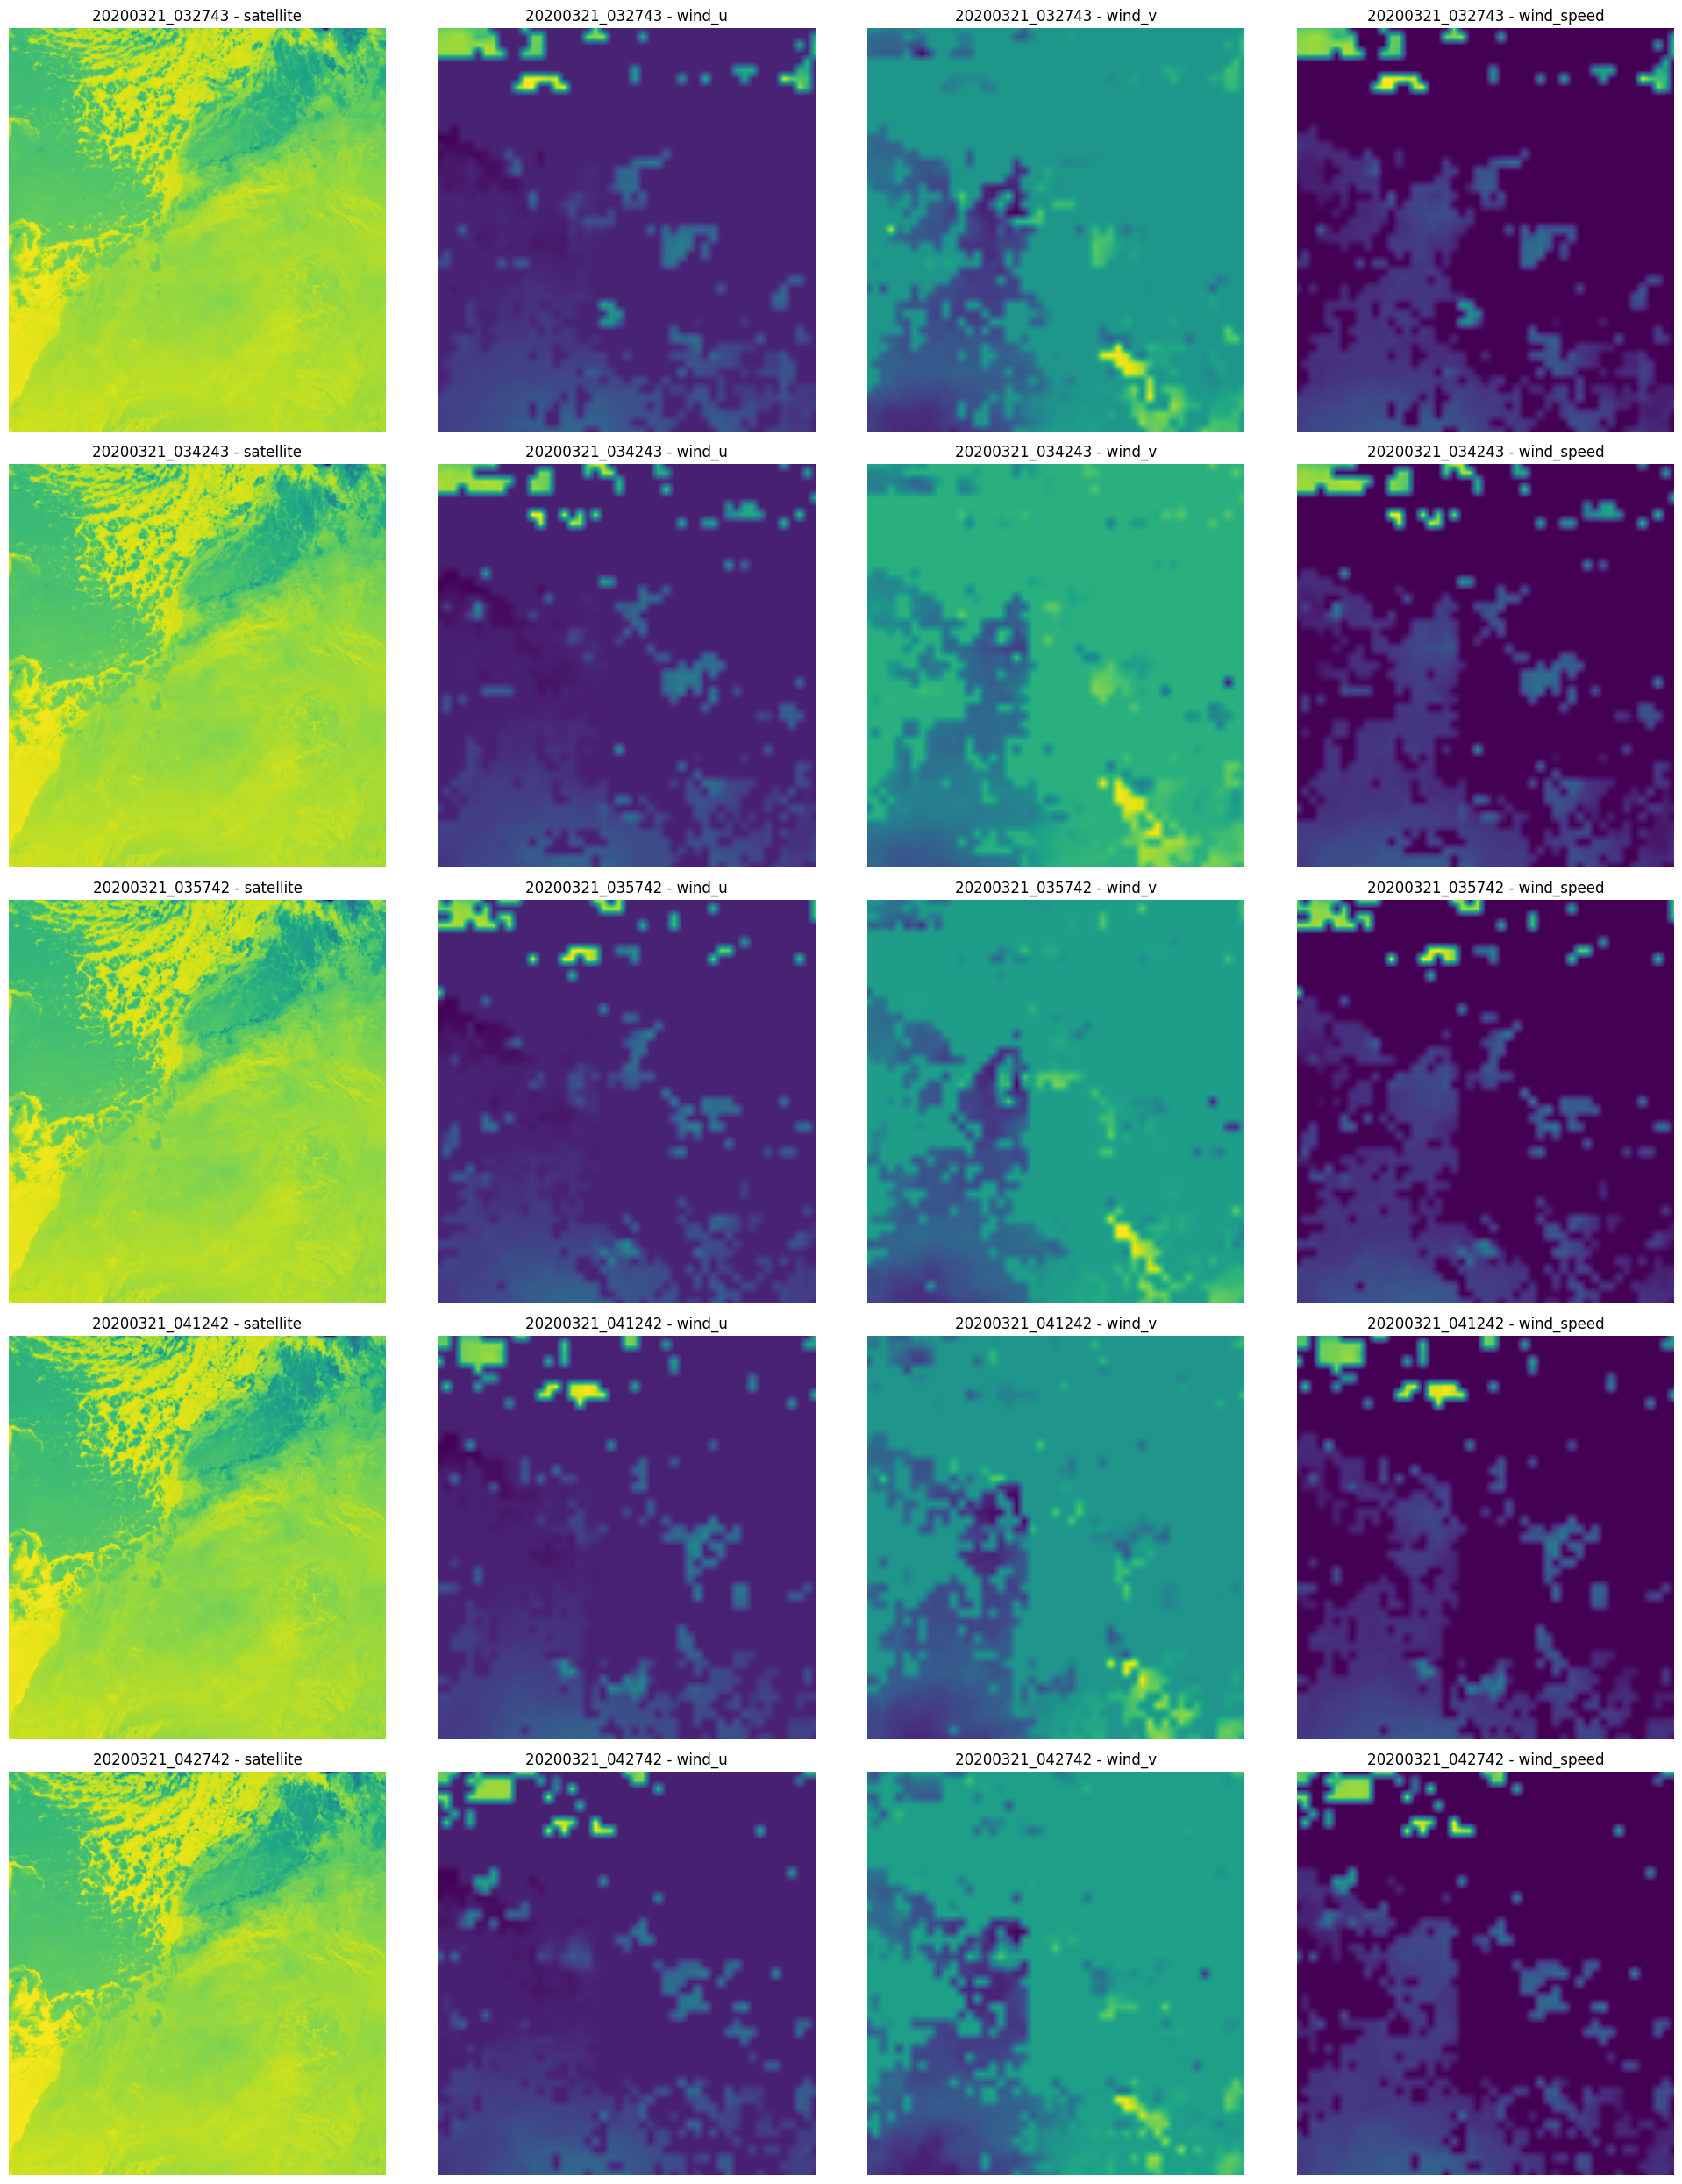

In [7]:
# Visualisation des 5 premiers timestamps
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
channel_names = ['satellite', 'wind_u', 'wind_v', 'wind_speed']

for i, file in enumerate(combined_files[:5]):
    data = np.load(file)
    timestamp = data['timestamp']
    print(f'Timestamp: {timestamp}')
    for j, ch in enumerate(channel_names):
        img = data['data'][j]
        axes[i, j].imshow(img, cmap='viridis')
        axes[i, j].set_title(f'{timestamp} - {ch}')
        axes[i, j].axis('off')
        print(f'  {ch}: min={img.min():.3f}, max={img.max():.3f}, mean={img.mean():.3f}')

plt.tight_layout()
plt.show()

20200321_032743
['satellite' 'wind_u' 'wind_v' 'wind_speed']


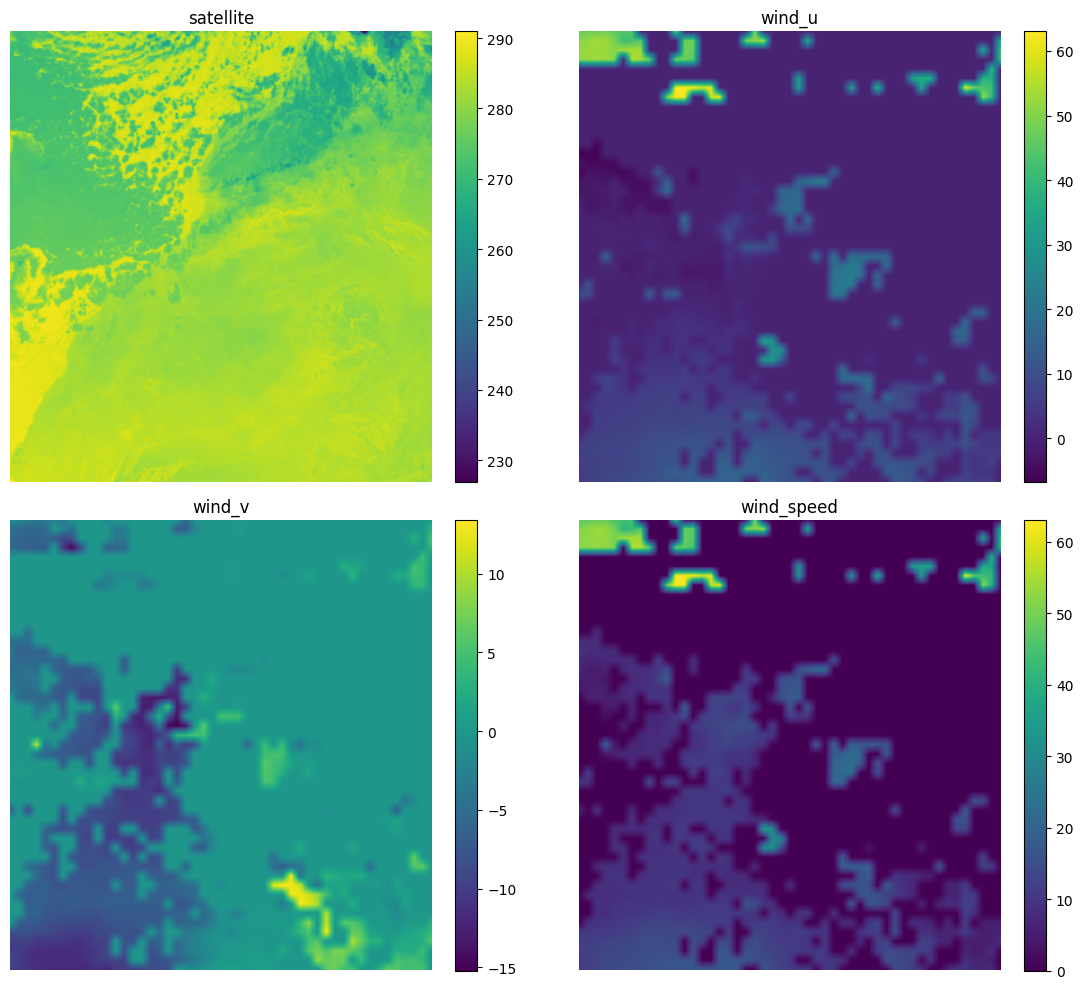

In [8]:
# Inspect the sample file content a bit more (timestamp, channel names) and visualize the 4 layers
import numpy as np
import matplotlib.pyplot as plt

sample_path = 'morocco_processed_dataset/combined/combined_20200321_032743.npz'
npz_obj = np.load(sample_path, allow_pickle=True)

timestamp_val = str(npz_obj['timestamp'])
channels_vals = npz_obj['channels']
print(timestamp_val)
print(channels_vals)

data_arr = npz_obj['data']

# Plot each channel as an image for intuition
plt.figure(figsize=(12, 10))
for i_ch in range(min(4, data_arr.shape[0])):
    plt.subplot(2, 2, i_ch + 1)
    plt.imshow(data_arr[i_ch], cmap='viridis')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(str(channels_vals[i_ch]))
    plt.axis('off')
plt.tight_layout()
plt.show()

**Structure d’un fichier .npz (très concret)**

J’ai ouvert un exemple et il contient 3 éléments :

    timestamp : l’instant du snapshot
    channels : les noms des couches
    data : les matrices 2D pour chaque couche, empilées

Dans l’exemple, le timestamp est :

20200321_032743

Et les canaux (couches) sont :

['satellite' 'wind_u' 'wind_v' 'wind_speed']
Ce que ça veut dire

    satellite : une image satellite (valeurs continues, typiquement intensité/reflectance selon le pré-traitement)
    wind_u : composante horizontale du vent (axe Est-Ouest)
    wind_v : composante verticale du vent (axe Nord-Sud)
    wind_speed : vitesse du vent (souvent calculée à partir de u et v)

Le tableau data a la forme (4, 557, 521) donc :

    4 canaux
    une grille spatiale de 557 x 521 pixels/cellules

